In [1]:
import pandas as pd
import numpy as np
# 1. Load Data
# Tambahkan 'data/' di depan nama file agar merujuk ke folder yang tepat
train_df = pd.read_csv('data/train.csv', low_memory=False)
store_df = pd.read_csv('data/store.csv', sep=';') 

In [2]:
# 2. Gabungkan data penjualan dengan info toko
df_full = pd.merge(train_df, store_df, how='left', on='Store')

In [3]:
# 3. Trik agar RAM aman: Ambil sampel 50.000 baris secara acak
# Hapus baris di mana toko tutup (Open == 0) atau Sales == 0
df_full = df_full[(df_full['Open'] != 0) & (df_full['Sales'] > 0)]
df = df_full.sample(n=500000, random_state=42) 

print("Data berhasil dimuat!")
print("Jumlah baris dan kolom saat ini:", df.shape)

Data berhasil dimuat!
Jumlah baris dan kolom saat ini: (500000, 18)


In [4]:
# Ubah format Date menjadi datetime
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
# Ekstrak fitur waktu
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [6]:
# Hapus kolom Date asli
df = df.drop(['Date'], axis=1)

In [7]:
# Mengatasi Missing Values tanpa menggunakan inplace=True
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())

In [8]:
# Sisa missing value (misal promo) diisi 0
df = df.fillna(0)

In [9]:
# Encoding Data Kategorikal (Mengubah teks jadi angka)
df = pd.get_dummies(df, columns=['StoreType', 'Assortment', 'StateHoliday', 'PromoInterval'], drop_first=True)

print("Tahap Preprocessing Selesai!")
print("Jumlah baris dan kolom sekarang:", df.shape)

Tahap Preprocessing Selesai!
Jumlah baris dan kolom sekarang: (500000, 27)


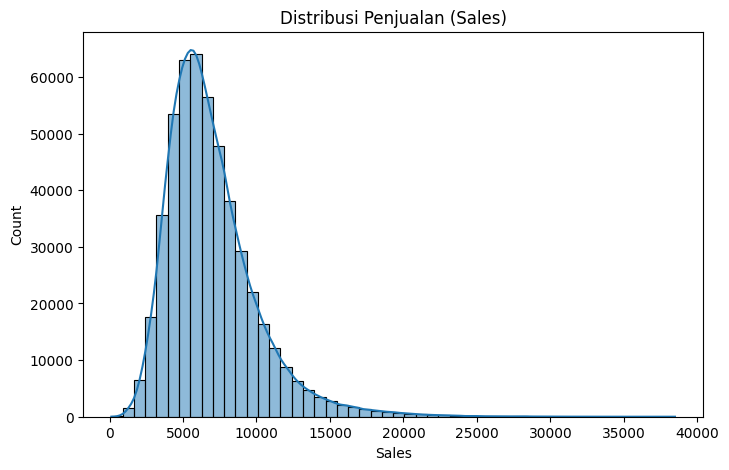

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribusi Penjualan
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title("Distribusi Penjualan (Sales)")
plt.show()

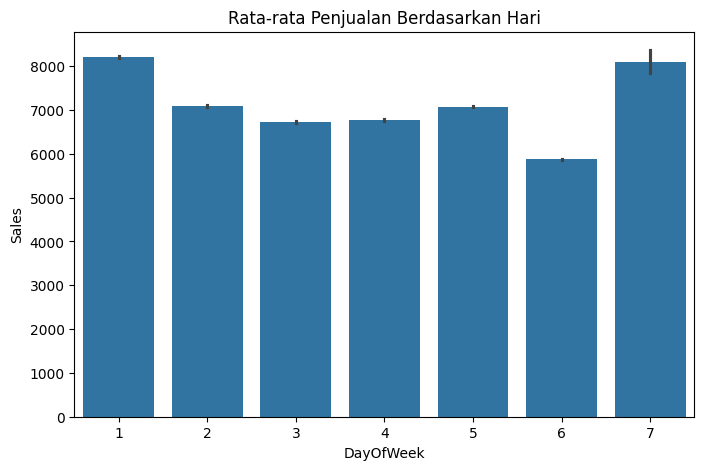

In [11]:
# Hubungan Hari dengan Penjualan
plt.figure(figsize=(8,5))
sns.barplot(x='DayOfWeek', y='Sales', data=df)
plt.title("Rata-rata Penjualan Berdasarkan Hari")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(['Sales', 'Customers'], axis=1) # Customers dihapus karena di masa depan kita tidak tau jumlah kustomer
y = df['Sales']

In [13]:
# Kombinasi 1: 70:30
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X, y, test_size=0.30, random_state=42)

In [14]:
# Kombinasi 2: 80:20
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X, y, test_size=0.20, random_state=42)

In [15]:
# Kombinasi 3: 90:10
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(X, y, test_size=0.10, random_state=42)

In [16]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

# --- Model 1: Hist Gradient Boosting (Target > 85%) ---
print("1. Training HistGradientBoosting...")
# Kita naikkan learning_rate dan jumlah iterasi agar lebih agresif
hgb = HistGradientBoostingRegressor(max_iter=350, learning_rate=0.15, max_leaf_nodes=60, random_state=42)
hgb.fit(X_train_80, y_train_80)
hgb_pred = hgb.predict(X_test_20)

1. Training HistGradientBoosting...


In [17]:
# --- Model 2: Random Forest (Target > 90%) ---
print("2. Training Random Forest...")
# Kita tambah jumlah pohon (n_estimators) menjadi 150
rf = RandomForestRegressor(n_estimators=150, max_depth=None, min_samples_split=2, random_state=42, n_jobs=-1)
rf.fit(X_train_80, y_train_80)
rf_pred = rf.predict(X_test_20)

2. Training Random Forest...


In [18]:
# --- Model 3: Decision Tree (Target > 85%) ---
print("3. Training Decision Tree...")
# Kita lepas GridSearchCV agar lebih cepat dan membiarkan pohon tumbuh tanpa batas maksimal
dt = DecisionTreeRegressor(max_depth=None, min_samples_split=5, min_samples_leaf=2, random_state=42)
dt.fit(X_train_80, y_train_80)
dt_pred = dt.predict(X_test_20)

3. Training Decision Tree...


In [19]:
# --- Evaluasi & Pembuatan Tabel ---
print("\nMenghitung Evaluasi...")
hasil = pd.DataFrame({
    'Model': ['Hist Gradient Boosting', 'Random Forest', 'Decision Tree (Tuned)'],
    'R2_Score (%)': [
        r2_score(y_test_20, hgb_pred) * 100, 
        r2_score(y_test_20, rf_pred) * 100, 
        r2_score(y_test_20, dt_pred) * 100
    ],
    'MAE': [
        mean_absolute_error(y_test_20, hgb_pred),
        mean_absolute_error(y_test_20, rf_pred),
        mean_absolute_error(y_test_20, dt_pred)
    ]
})

print("\n--- Tabel Perbandingan Akhir ---")
print(hasil)


Menghitung Evaluasi...

--- Tabel Perbandingan Akhir ---
                    Model  R2_Score (%)         MAE
0  Hist Gradient Boosting     91.536281  625.523451
1           Random Forest     89.465249  632.933680
2   Decision Tree (Tuned)     82.617661  808.848908
